# 🧾 AI Resume Screening System

This project builds a simple AI system that ranks resumes based on how well they match a job description.

Steps in this project:

1. Import required libraries
2. Extract text from resume PDFs
3. Clean and preprocess text
4. Convert text to numerical features using TF-IDF
5. Calculate similarity between resumes and job description
6. Rank resumes based on similarity scores

## Install required libraries
- In this step we install all the libraries required for the project.

In [59]:
# Install required libraries
!pip install PyPDF2

## Import Required Libraries
- In this step we import all the libraries required for the project.

In [60]:
# Import required libraries 
import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

import re  
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

from wordcloud import WordCloud
from collections import Counter

# For reading PDFs 
import PyPDF2 

# NLP Libraries 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Extract Text from Resume PDF
Resumes are usually stored as PDF files.  
Before applying NLP techniques, we must extract the text from these PDFs.

In [61]:
# Function to extract text from a PDF resume
def extract_text(pdf_path): 
    text = ""
    num_pages = 0
    with open(pdf_path,"rb") as f: 
        reader = PyPDF2.PdfReader(f)
        
        num_pages = len(reader.pages)

        for page in reader.pages: 
            text += page.extract_text()
            
    return text, num_pages

# Folder containing resumes 
resume_folder = "data/resumes/"

# List to store resume texts 
resume_text = [] 

# List to store resume file names 
resume_name = [] 

# List to store number of pages in a resume 
resume_pages = []

# Loop throgh all files in thefolder 
for file in os.listdir(resume_folder): 
    if file.endswith(".pdf"): 
        pdf_path = os.path.join(resume_folder, file) 
        text, num_pages = extract_text(pdf_path)

        # filter resumes longer than 3 pages 
        if num_pages <=3 : 
            resume_text.append(text) 
            resume_name.append(file) 
            resume_pages.append(num_pages)
        else: 
            print(f"{file} **REJECTED** (more than 3 pages)")

# Create Dataframe for resumes 
resume_df = pd.DataFrame({
    "Name" : resume_name, 
    "Text" : resume_text,
    "Pages" : resume_pages
})

print(resume_df)
print("\n")
print("Total resumes loaded :", len(resume_text))

          Name                                               Text  Pages
0  fake CV.pdf  FAKE NAME\nPhone: \nemailADDRESS\nI'm a studen...      3
1  resume1.pdf  Ashish Kumar\nPhone: +917037764252\nEmail: akn...      2
2  resume2.pdf  Functional Resume Sample \n \nJohn W. Smith   ...      1


Total resumes loaded : 3


## Add Job Description

In order to rank resumes, we need a job description.  
The system will compare each resume with this job description to determine how relevant the candidate is for the role.
Instead of hardcoding a job description, we create a function that allows the recruiter or interviewer to provide a job description dynamically.
This makes the system flexible and usable for different job roles.

In [63]:
# Function to get job description
def get_job_description(): 
    description = input("Enter the job description : ") 

    return description

job_description = get_job_description()

print("\nJob Description:\n")
print(job_description)

Enter the job description :  We are looking for a Data Scientist who can bridge the gap between raw information and strategic action. You won't just build models in isolation; you will solve complex business problems, optimize organizational performance, and use Generative AI and automation to accelerate the path from data to decision. The ideal candidate is a "full-stack" data thinker—someone as comfortable performing deep-dive statistical analysis as they are deploying a RAG-based LLM application. Key Responsibilities Exploratory Data Analysis (EDA): Masterfully clean and investigate messy datasets using Python (Pandas, NumPy) to uncover hidden patterns and data quality issues. Predictive Modeling: Design, train, and tune Machine Learning (ML) and Deep Learning (DL) models to forecast trends and automate classification tasks. GenAI & LLM Integration: Build and optimize Generative AI workflows, including implementing RAG (Retrieval-Augmented Generation) and prompt engineering to solve


Job Description:

We are looking for a Data Scientist who can bridge the gap between raw information and strategic action. You won't just build models in isolation; you will solve complex business problems, optimize organizational performance, and use Generative AI and automation to accelerate the path from data to decision. The ideal candidate is a "full-stack" data thinker—someone as comfortable performing deep-dive statistical analysis as they are deploying a RAG-based LLM application. Key Responsibilities Exploratory Data Analysis (EDA): Masterfully clean and investigate messy datasets using Python (Pandas, NumPy) to uncover hidden patterns and data quality issues. Predictive Modeling: Design, train, and tune Machine Learning (ML) and Deep Learning (DL) models to forecast trends and automate classification tasks. GenAI & LLM Integration: Build and optimize Generative AI workflows, including implementing RAG (Retrieval-Augmented Generation) and prompt engineering to solve internal 

## Text Preprocessing
The preprocessing steps include:
- converting text to lowercase
- removing numbers
- removing punctuation
- removing extra spaces

This helps standardize the text so that the model focuses on meaningful words.

In [64]:
# Defining stopwords
stop_words = set(stopwords.words("english")) 

# Function to clean text
def clean_text(text): 
    text = text.lower() 
    text = re.sub('[^a-zA-Z]',' ',text) 
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.split() 
    text = [word for word in text if word not in stop_words]
    text = ' '.join(text)
    
    return text

In [65]:
# Apply cleaning to resume text
resume_df['Cleaned_text'] = resume_df['Text'].apply(clean_text)

In [66]:
resume_df

,Name,Text,Pages,Cleaned_text
0,fake CV.pdf,FAKE NAME\nPhone: \nemailADDRESS\nI'm a studen...,3,fake name phone emailaddress student studying ...
1,resume1.pdf,Ashish Kumar\nPhone: +917037764252\nEmail: akn...,2,ashish kumar phone email aknexa gmail com link...
2,resume2.pdf,Functional Resume Sample \n \nJohn W. Smith ...,1,functional resume sample john w smith front ra...


In [67]:
# Clean job job_description
cleaned_job_description = clean_text(job_description)

print(cleaned_job_description)

looking data scientist bridge gap raw information strategic action build models isolation solve complex business problems optimize organizational performance use generative ai automation accelerate path data decision ideal candidate full stack data thinker someone comfortable performing deep dive statistical analysis deploying rag based llm application key responsibilities exploratory data analysis eda masterfully clean investigate messy datasets using python pandas numpy uncover hidden patterns data quality issues predictive modeling design train tune machine learning ml deep learning dl models forecast trends automate classification tasks genai llm integration build optimize generative ai workflows including implementing rag retrieval augmented generation prompt engineering solve internal external user needs natural language processing nlp apply nlp techniques extract sentiment entities intent unstructured text data statistical validation use statistics b testing ensure model outputs

## Word Frequency Visualization for Resumes 
This helps understand which terms appear most often in candidate resumes and provides insight into the dataset.

In [68]:
# Combine all resume texts  
all_resume_text = " ".join(resume_df['Cleaned_text'])

wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

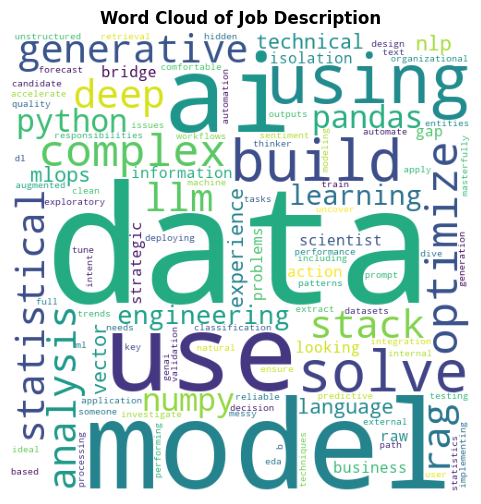

In [69]:
# Wordcloud for job dejob_description
job_wc = wc.generate(cleaned_job_description)
plt.figure(figsize=(6,6))
plt.imshow(job_wc)
plt.axis("off")
plt.title("Word Cloud of Job Description",fontweight='bold')
plt.show()

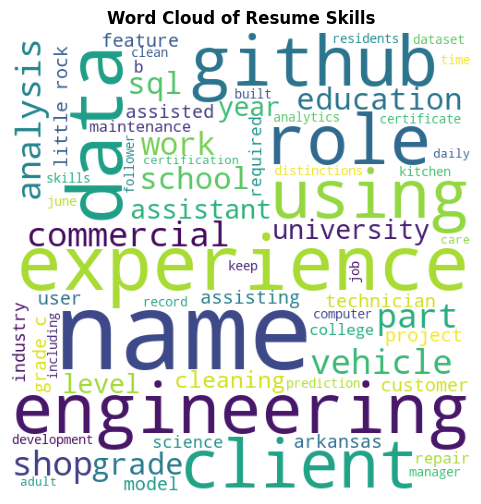

In [70]:
# Wordcloud for resumes 
resume_wc = wc.generate(all_resume_text)
plt.figure(figsize=(6,6))
plt.imshow(resume_wc)
plt.axis("off")
plt.title("Word Cloud of Resume Skills",fontweight='bold')
plt.show()

## Top 10 words in Job Description

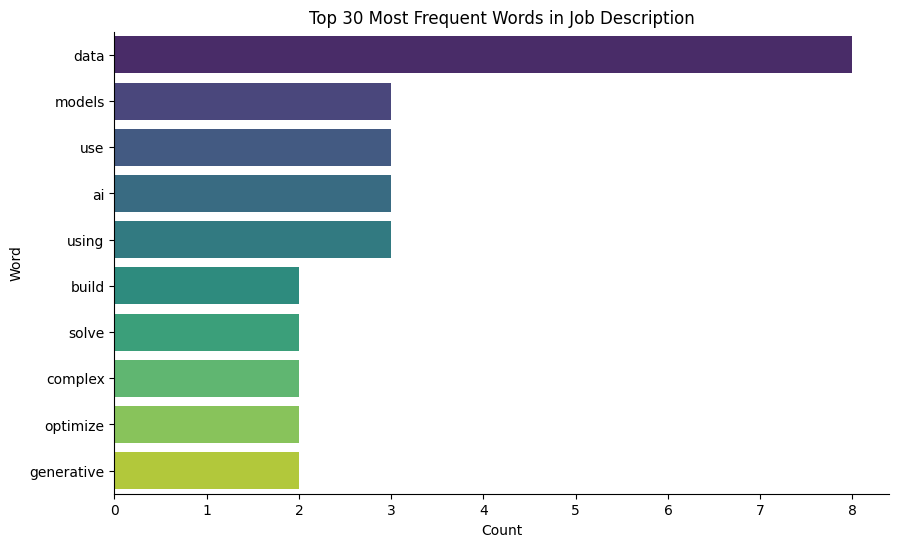

In [72]:
# Top 30 words in resume
job_words = cleaned_job_description.split()
word_counts = Counter(job_words)
top_words = pd.DataFrame(word_counts.most_common(10), columns=["Word", "Count"])

plt.figure(figsize=(10,6))
sns.barplot(x="Count", y="Word", data=top_words, palette="viridis")

plt.title("Top 30 Most Frequent Words in Job Description")
sns.despine()
plt.show()

## Top 10 words in Resume

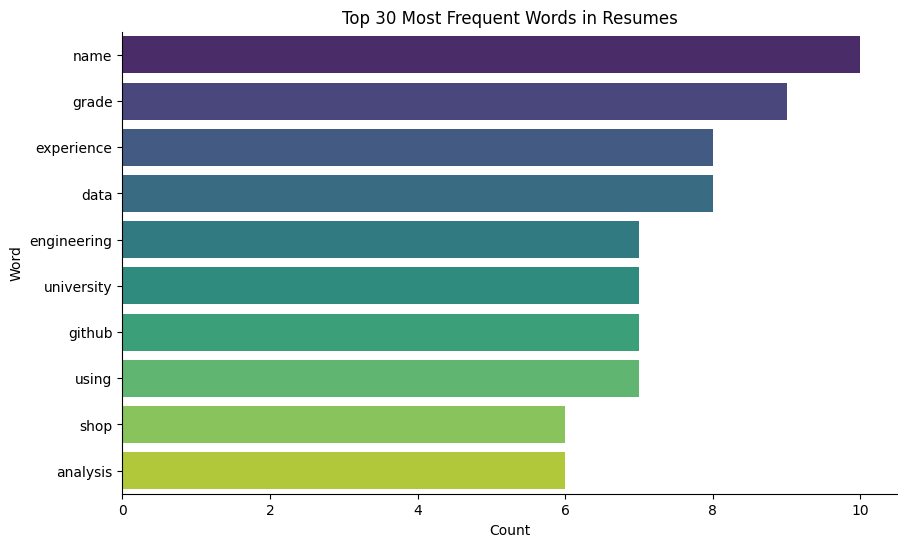

In [74]:
# Top 30 words in resume
resume_words = all_resume_text.split()
word_counts = Counter(resume_words)
top_words = pd.DataFrame(word_counts.most_common(10), columns=["Word", "Count"])

plt.figure(figsize=(10,6))
sns.barplot(x="Count", y="Word", data=top_words, palette="viridis")

plt.title("Top 30 Most Frequent Words in Resumes")
sns.despine()
plt.show()

## Text Vectorization
Machine learning models cannot understand raw text.  
Therefore we convert text into numerical vectors using TF-IDF (Term Frequency – Inverse Document Frequency).

TF-IDF assigns importance to words based on how frequently they appear in a document compared to all documents.

In [75]:
# Applying TF-IDF 
vectorizer = TfidfVectorizer(
    max_features=3000, 
    ngram_range=(1,2), 
    sublinear_tf=True
)

## Combine Job Description and Resumes

To compare resumes with the job description, we combine them into a single list of documents.

The first document will be the job description, and the remaining documents will be the resumes.

In [76]:
# Combine job description and resume texts
all_doucments = [cleaned_job_description] + resume_df['Cleaned_text'].tolist()

print("Total documents :",len(all_doucments))

Total documents : 4


In [77]:
# Convert text into tf-idf vectors  
tfidf_matrix = vectorizer.fit_transform(all_doucments)

print(f"Number of Documents : {tfidf_matrix.shape[0]}")
print(f"Number of Unique Words: {tfidf_matrix.shape[1]}")

Number of Documents : 4
Number of Unique Words: 1725


In [78]:
vectorizer.get_feature_names_out()[:20]

array(['ability', 'ability explain', 'accelerate', 'accelerate path',
       'accepted', 'accepted position', 'access', 'access engineering',
       'achieved', 'achieved level', 'action', 'action build',
       'actionable', 'actionable engagement', 'active', 'active engaged',
       'activities', 'activities employment', 'activities oversaw',
       'activity'], dtype=object)

## Calculate Cosine Similarity

Cosine similarity measures the similarity between two vectors.

Here we calculate the similarity between the job description and each resume to determine how well the candidate matches the job requirements.

In [79]:
# Calculate cosine similarity 
similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:])

similarity

array([[0.02731364, 0.08555592, 0.01056192]])

In [88]:
similarity_score = similarity.flatten() 

resume_df['Similarity Score'] = similarity_score
resume_df

,Name,Text,Pages,Cleaned_text,Similarity Score
0,fake CV.pdf,FAKE NAME\nPhone: \nemailADDRESS\nI'm a studen...,3,fake name phone emailaddress student studying ...,0.027314
1,resume1.pdf,Ashish Kumar\nPhone: +917037764252\nEmail: akn...,2,ashish kumar phone email aknexa gmail com link...,0.085556
2,resume2.pdf,Functional Resume Sample \n \nJohn W. Smith ...,1,functional resume sample john w smith front ra...,0.010562


## Top Matching Resumes

After calculating similarity scores, we display the resumes ranked from highest to lowest match with the job description.

In [89]:
# Sort resumes by similarity score
ranked_resumes = resume_df.sort_values(
    by = "Similarity Score", 
    ascending=False
)

ranked_resumes[['Name','Similarity Score']]

,Name,Similarity Score
1,resume1.pdf,0.085556
0,fake CV.pdf,0.027314
2,resume2.pdf,0.010562


## Best Candidate

Here is the Best Candidate for the perticular job description among all the resumes 

In [95]:
best_candidate = ranked_resumes.iloc[0]

print("Best Candidate :",best_candidate['Name'])
print(f"Similarity Score : {best_candidate['Similarity Score']:.3f}")

Best Candidate : resume1.pdf
Similarity Score : 0.086


## Visualize Resume Similarity Scores

To better understand the results, we visualize the similarity scores of resumes compared to the job description.

Higher similarity indicates a stronger match with the job requirements.

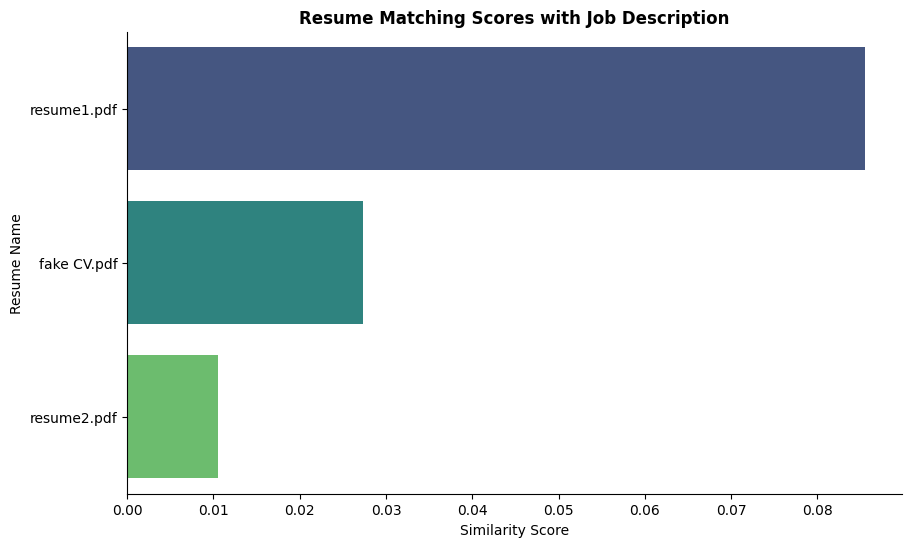

In [99]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Similarity Score', 
    y='Name', 
    data=ranked_resumes, 
    palette='viridis'
)
plt.title("Resume Matching Scores with Job Description",fontweight='bold')
plt.xlabel("Similarity Score")
plt.ylabel("Resume Name")
sns.despine()
plt.show()